### 3. Calcular mapas de fracción de wet days en los dos datasets

# Wet days y precipitación media: CR2MET vs ALADIN (dominio común)

Comparación en el periodo histórico **1980-2014** con wet day **pr ≥ 1 mm/día**.

**Dominio espacial común** (números consolidados y mapas):
- Máscara: **Chile continental** (Natural Earth `admin_0_countries`, resolución 10m).
- Grilla de referencia: **ALADIN CHP12** (`y` × `x`, coordenadas `lat`/`lon` 2D).
- **CR2MET** se interpola linealmente a esa grilla (`scipy` vía `xarray.interp`).
- **ALADIN** permanece en su grilla nativa; ambos se enmascaran con el mismo polígono.

La primera celda de código imprime el registro del dominio (celdas válidas, límites geográficos, método de regrillado).

Al final del notebook, los **mapas de diferencia (ALADIN − CR2MET)** incluyen **significancia por bootstrap por años** (IC95; hachurado donde la diferencia es significativa).

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from IPython.display import display
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep

try:
    import scipy  # requerido por xarray.interp(method='linear')
except ImportError as exc:
    raise ImportError(
        "Este notebook necesita scipy para regrillar CR2MET sobre ALADIN. "
        "Instala con: pip install scipy"
    ) from exc

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = False

# =====================================================================
# CONFIGURACION GENERAL
# =====================================================================
START_DATE = '1980-01-01'
END_DATE = '2014-12-31'
WET_THRESHOLD = 1.0  # mm/dia
BOOTSTRAP_ITER = 1000
RANDOM_SEED = 42
ALPHA = 0.05  # IC95 para significancia (IC no incluye 0)
CHILE_EXTENT = [-76, -65, -55, -17]  # zoom cartografico en mapas

DOMAIN_MASK_NAME = 'Chile continental (Natural Earth admin_0_countries)'
DOMAIN_MASK_RESOLUTION = '10m'
REFERENCE_GRID = 'ALADIN CHP12 curvilinear (dimensiones y x, lat/lon 2D)'
CR2MET_REGRID_METHOD = 'interpolacion lineal de xarray a lat/lon de ALADIN (requiere scipy)'

# =====================================================================
# DOMINIO ESPACIAL COMUN
# =====================================================================
def load_chile_geometry():
    shp_path = shpreader.natural_earth(
        resolution=DOMAIN_MASK_RESOLUTION,
        category='cultural',
        name='admin_0_countries',
    )
    reader = shpreader.Reader(shp_path)
    geoms = [
        record.geometry
        for record in reader.records()
        if record.attributes.get('NAME') == 'Chile'
        or record.attributes.get('ADMIN') == 'Chile'
    ]
    if not geoms:
        raise RuntimeError('No se encontro Chile en Natural Earth admin_0_countries')
    return unary_union(geoms)


def build_chile_mask_on_aladin_grid(lat2d, lon2d, geometry):
    """Mascara booleana en centros de celda (grilla curvilinea ALADIN)."""
    prepared = prep(geometry)
    flat_mask = np.fromiter(
        (
            prepared.contains(Point(x, y)) or geometry.touches(Point(x, y))
            for y, x in zip(lat2d.ravel(), lon2d.ravel())
        ),
        dtype=bool,
        count=lat2d.size,
    )
    return flat_mask.reshape(lat2d.shape)


def describe_common_domain(mask_da):
    active = mask_da.values
    lat_vals = mask_da['lat'].values[active]
    lon_vals = mask_da['lon'].values[active]
    return {
        'periodo': f'{START_DATE} a {END_DATE}',
        'wet_day': f'pr >= {WET_THRESHOLD} mm/dia',
        'mascara': DOMAIN_MASK_NAME,
        'resolucion_mascara': DOMAIN_MASK_RESOLUTION,
        'grilla_referencia': REFERENCE_GRID,
        'regrillado_cr2met': CR2MET_REGRID_METHOD,
        'celdas_validas': int(active.sum()),
        'celdas_totales_grilla': int(active.size),
        'fraccion_grilla_usada': float(active.sum() / active.size),
        'lat_min': float(lat_vals.min()),
        'lat_max': float(lat_vals.max()),
        'lon_min': float(lon_vals.min()),
        'lon_max': float(lon_vals.max()),
    }


# =====================================================================
# CARGA Y REGRILLADO
# =====================================================================
def open_aladin_historical():
    ds = xr.open_mfdataset('./pr1/pr_CHP12_*_historical_*.nc', use_cftime=True, chunks={'time': 365})
    return ds['pr'].sel(time=slice(START_DATE, END_DATE)) * 86400.0


def open_cr2met_historical():
    ds = xr.open_mfdataset('./pr/CR2MET_pr_v2.5_day_*.nc', chunks={'time': 365})
    return ds['pr'].sel(time=slice(START_DATE, END_DATE))


def regrid_cr2met_to_aladin(pr_cr2met, pr_aladin_template):
    """Interpola CR2MET (lat/lon 1D) a la grilla curvilinea de ALADIN."""
    return pr_cr2met.interp(
        lat=pr_aladin_template['lat'],
        lon=pr_aladin_template['lon'],
        method='linear',
    )


def apply_domain_mask(data_array, mask_da):
    return data_array.where(mask_da)


def normalize_daily_time(da):
    """Unifica fechas diarias (cftime 12:00 vs datetime64 00:00) para alinear productos."""
    dates = pd.DatetimeIndex([pd.Timestamp(str(t)[:10]) for t in da['time'].values])
    return da.assign_coords(time=dates).groupby('time').mean()


# =====================================================================
# METRICAS
# =====================================================================
def wet_day_fraction(pr):
    return (pr >= WET_THRESHOLD).mean(dim='time') * 100.0


def mean_precip_all_days(pr):
    return pr.mean(dim='time')


def mean_precip_wet_days(pr):
    wet_only = pr.where(pr >= WET_THRESHOLD)
    return wet_only.mean(dim='time', skipna=True)


def summarize_field_masked(field, mask_da, dataset_name, metric_name, units, domain_label):
    values = field.where(mask_da).values.ravel()
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise RuntimeError(f'Sin celdas validas para {dataset_name} - {metric_name}')
    return {
        'Dominio': domain_label,
        'Dataset': dataset_name,
        'Metrica': metric_name,
        'Unidades': units,
        'Celdas en dominio': int(values.size),
        'Promedio espacial': float(np.mean(values)),
        'Mediana espacial': float(np.median(values)),
        'Minimo espacial': float(np.min(values)),
        'Maximo espacial': float(np.max(values)),
    }




def years_from_time(time_coord):
    """Extrae el ano calendario (compatible con cftime y numpy datetime64)."""
    tvals = time_coord.values
    if hasattr(tvals[0], 'year'):
        return np.array([t.year for t in tvals], dtype=int)
    return pd.to_datetime(tvals).year.to_numpy()


def add_year_coord(da):
    return da.assign_coords(year=('time', years_from_time(da['time'])))


def annual_wet_day_fraction(pr):
    pr = add_year_coord(pr)
    return (pr >= WET_THRESHOLD).groupby('year').mean('time') * 100.0


def annual_mean_precip_all_days(pr):
    return add_year_coord(pr).groupby('year').mean('time')


def annual_mean_precip_wet_days(pr):
    pr = add_year_coord(pr)
    return pr.where(pr >= WET_THRESHOLD).groupby('year').mean('time', skipna=True)


def bootstrap_paired_mean_diff(annual_left, annual_right, *, n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED):
    """Bootstrap por anos de la diferencia media (right - left), p. ej. ALADIN - CR2MET."""
    delta = (annual_right - annual_left).compute()
    vals = delta.values
    n_years = vals.shape[0]
    flat = vals.reshape(n_years, -1)
    n_cells = flat.shape[1]

    rng = np.random.default_rng(seed)
    boot = np.empty((n_iter, n_cells), dtype=np.float64)
    for b in range(n_iter):
        idx = rng.integers(0, n_years, size=n_years)
        boot[b] = np.nanmean(flat[idx], axis=0)

    obs_mean = np.nanmean(flat, axis=0)
    ci_low = np.nanpercentile(boot, 100 * ALPHA / 2, axis=0)
    ci_high = np.nanpercentile(boot, 100 * (1 - ALPHA / 2), axis=0)

    significant = (ci_low > 0) | (ci_high < 0)
    sig_higher = ci_low > 0
    sig_lower = ci_high < 0

    shape_2d = vals.shape[1:]
    coords = {d: delta.coords[d] for d in delta.dims[1:]}
    dims = delta.dims[1:]

    def _da(arr_flat, name):
        return xr.DataArray(
            arr_flat.reshape(shape_2d),
            coords=coords,
            dims=dims,
            name=name,
        ).assign_coords(lon=delta['lon'], lat=delta['lat'])

    return {
        'mean_diff': _da(obs_mean, 'mean_diff'),
        'ci_low': _da(ci_low, 'ci_low'),
        'ci_high': _da(ci_high, 'ci_high'),
        'significant': _da(significant, 'significant'),
        'sig_higher': _da(sig_higher, 'sig_higher'),
        'sig_lower': _da(sig_lower, 'sig_lower'),
    }


def summarize_bootstrap_map(diff_da, sig_da, sig_higher_da, metric_label, units):
    data = diff_da.where(chile_mask).values.ravel()
    sig = sig_da.where(chile_mask).values.ravel().astype(bool)
    sig_hi = sig_higher_da.where(chile_mask).values.ravel().astype(bool)
    valid = np.isfinite(data)
    data, sig, sig_hi = data[valid], sig[valid], sig_hi[valid]
    return {
        'Metrica': metric_label,
        'Unidades delta': units,
        'Delta medio espacial': float(np.mean(data)),
        'Delta mediano espacial': float(np.median(data)),
        '% celdas significativas': float(np.mean(sig) * 100.0),
        '% ALADIN > CR2MET (sig.)': float(np.mean(sig_hi) * 100.0),
        '% ALADIN < CR2MET (sig.)': float(np.mean(sig & ~sig_hi) * 100.0),
    }


def plot_diff_map_with_bootstrap(diff_da, significant_da, *, title, cbar_label, cmap='RdBu', vmin=None, vmax=None):
    vals = diff_da.where(chile_mask).values.ravel()
    vals = vals[np.isfinite(vals)]
    if vmin is None or vmax is None:
        lim = float(np.nanpercentile(np.abs(vals), 98)) if vals.size else 1.0
        lim = max(lim, 0.01)
        if vmin is None:
            vmin = -lim
        if vmax is None:
            vmax = lim

    fig, ax = plt.subplots(1, 1, figsize=(8.5, 6.5), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent(CHILE_EXTENT)

    im = diff_da.plot.pcolormesh(
        ax=ax,
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )

    sig_mask = xr.where(significant_da, 1.0, np.nan)
    ax.contourf(
        diff_da['lon'],
        diff_da['lat'],
        sig_mask,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['....'],
        transform=ccrs.PlateCarree(),
    )

    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.8, pad=0.07)
    cbar.set_label(cbar_label)
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()




def plot_two_panel_maps(left_data, right_data, *, title, cbar_label, cmap, vmin=None, vmax=None):
    fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    panels = [
        ('CR2MET interpolado a ALADIN', left_data),
        ('ALADIN historico (grilla nativa)', right_data),
    ]

    im = None
    for ax, (panel_title, data) in zip(axes, panels):
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.set_extent(CHILE_EXTENT)
        im = data.plot.pcolormesh(
            ax=ax,
            x='lon',
            y='lat',
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
        )
        ax.set_title(panel_title, fontweight='bold', fontsize=12)

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.7, pad=0.06)
    cbar.set_label(cbar_label)
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.95)
    plt.show()


print('1/4: Cargando datos historicos de CR2MET y ALADIN...')
pr_aladin = open_aladin_historical()
pr_cr2met_native = open_cr2met_historical()

chile_geom = load_chile_geometry()
chile_mask_bool = build_chile_mask_on_aladin_grid(
    pr_aladin['lat'].values,
    pr_aladin['lon'].values,
    chile_geom,
)
chile_mask = xr.DataArray(
    chile_mask_bool,
    coords={'y': pr_aladin['y'], 'x': pr_aladin['x'], 'lat': pr_aladin['lat'], 'lon': pr_aladin['lon']},
    dims=['y', 'x'],
    name='chile_mask',
)

DOMAIN_INFO = describe_common_domain(chile_mask)
DOMAIN_LABEL = 'Chile (mascara Natural Earth sobre grilla ALADIN)'

print('2/4: Regrillando CR2MET a la grilla ALADIN y aplicando mascara...')
pr_cr2met = regrid_cr2met_to_aladin(pr_cr2met_native, pr_aladin)

# Periodo temporal comun (obligatorio para comparacion pareada y bootstrap)
pr_cr2met = normalize_daily_time(pr_cr2met)
pr_aladin = normalize_daily_time(pr_aladin)
pr_cr2met, pr_aladin = xr.align(pr_cr2met, pr_aladin, join='inner')
if pr_cr2met.sizes.get('time', 0) == 0:
    raise RuntimeError('Sin fechas comunes entre CR2MET y ALADIN tras normalizar tiempo diario.')
N_YEARS_COMMON = int(len(np.unique(years_from_time(pr_aladin['time']))))
TIME_START_COMMON = str(pr_aladin['time'].values[0])[:10]
TIME_END_COMMON = str(pr_aladin['time'].values[-1])[:10]

pr_cr2met_chile = apply_domain_mask(pr_cr2met, chile_mask)
pr_aladin_chile = apply_domain_mask(pr_aladin, chile_mask)

print('\n--- DOMINIO ESPACIAL COMUN (documentacion) ---')
for key, value in DOMAIN_INFO.items():
    print(f'  {key}: {value}')
print('  nota_mapas: mismos campos enmascarados en grilla ALADIN; zoom CHILE_EXTENT')
print('----------------------------------------------\n')

print(f'Periodo solicitado: {START_DATE} a {END_DATE}')
print(f'Periodo efectivo (interseccion CR2MET-ALADIN): {TIME_START_COMMON} a {TIME_END_COMMON} ({N_YEARS_COMMON} anos)')
print(f'Umbral wet day: pr >= {WET_THRESHOLD:.1f} mm/dia')
print('ALADIN: kg m-2 s-1 -> mm/dia (x86400). CR2MET: ya en mm/dia.')


1/4: Cargando datos historicos de CR2MET y ALADIN...
2/4: Regrillando CR2MET a la grilla ALADIN y aplicando mascara...

--- DOMINIO ESPACIAL COMUN (documentacion) ---
  periodo: 1980-01-01 a 2014-12-31
  wet_day: pr >= 1.0 mm/dia
  mascara: Chile continental (Natural Earth admin_0_countries)
  resolucion_mascara: 10m
  grilla_referencia: ALADIN CHP12 curvilinear (dimensiones y x, lat/lon 2D)
  regrillado_cr2met: interpolacion lineal de xarray a lat/lon de ALADIN (requiere scipy)
  celdas_validas: 3587
  celdas_totales_grilla: 17340
  fraccion_grilla_usada: 0.2068627450980392
  lat_min: -45.87698700780834
  lat_max: -17.65606323225109
  lon_min: -74.59472449350642
  lon_max: -67.03261824260926
  nota_mapas: mismos campos enmascarados en grilla ALADIN; zoom CHILE_EXTENT
----------------------------------------------

Periodo solicitado: 1980-01-01 a 2014-12-31
Periodo efectivo (interseccion CR2MET-ALADIN): 1980-01-01 a 2014-12-31 (35 anos)
Umbral wet day: pr >= 1.0 mm/dia
ALADIN: kg m-2 

In [6]:
# =====================================================================
# CALCULO DE LAS TRES METRICAS (DOMINIO COMUN)
# =====================================================================
print('3/4: Calculando metricas sobre el dominio comun de Chile...')

wet_frac_cr2met = wet_day_fraction(pr_cr2met_chile).compute()
wet_frac_aladin = wet_day_fraction(pr_aladin_chile).compute()

mean_all_cr2met = mean_precip_all_days(pr_cr2met_chile).compute()
mean_all_aladin = mean_precip_all_days(pr_aladin_chile).compute()

mean_wet_cr2met = mean_precip_wet_days(pr_cr2met_chile).compute()
mean_wet_aladin = mean_precip_wet_days(pr_aladin_chile).compute()

summary_rows = [
    summarize_field_masked(wet_frac_cr2met, chile_mask, 'CR2MET', 'Fraccion de wet days', '%', DOMAIN_LABEL),
    summarize_field_masked(wet_frac_aladin, chile_mask, 'ALADIN historico', 'Fraccion de wet days', '%', DOMAIN_LABEL),
    summarize_field_masked(mean_all_cr2met, chile_mask, 'CR2MET', 'Precipitacion media sobre todos los dias', 'mm/dia', DOMAIN_LABEL),
    summarize_field_masked(mean_all_aladin, chile_mask, 'ALADIN historico', 'Precipitacion media sobre todos los dias', 'mm/dia', DOMAIN_LABEL),
    summarize_field_masked(mean_wet_cr2met, chile_mask, 'CR2MET', 'Precipitacion media solo en wet days', 'mm/dia lluvioso', DOMAIN_LABEL),
    summarize_field_masked(mean_wet_aladin, chile_mask, 'ALADIN historico', 'Precipitacion media solo en wet days', 'mm/dia lluvioso', DOMAIN_LABEL),
]

summary_table = pd.DataFrame(summary_rows)
domain_table = pd.DataFrame([DOMAIN_INFO])

display(domain_table.T.rename(columns={0: 'valor'}))
display(summary_table.round(3))


3/4: Calculando metricas sobre el dominio comun de Chile...


,valor
periodo,1980-01-01 a 2014-12-31
wet_day,pr >= 1.0 mm/dia
mascara,Chile continental (Natural Earth admin_0_count...
resolucion_mascara,10m
grilla_referencia,"ALADIN CHP12 curvilinear (dimensiones y x, lat..."
regrillado_cr2met,interpolacion lineal de xarray a lat/lon de AL...
celdas_validas,3587
celdas_totales_grilla,17340
fraccion_grilla_usada,0.206863
lat_min,-45.876987


,Dominio,Dataset,Metrica,Unidades,Celdas en dominio,Promedio espacial,Mediana espacial,Minimo espacial,Maximo espacial
0,Chile (mascara Natural Earth sobre grilla ALADIN),CR2MET,Fraccion de wet days,%,3587,20.945,11.945,0.047,76.705
1,Chile (mascara Natural Earth sobre grilla ALADIN),ALADIN historico,Fraccion de wet days,%,3587,30.685,26.486,0.673,83.229
2,Chile (mascara Natural Earth sobre grilla ALADIN),CR2MET,Precipitacion media sobre todos los dias,mm/dia,3587,2.596,0.800,0.002,14.258
3,Chile (mascara Natural Earth sobre grilla ALADIN),ALADIN historico,Precipitacion media sobre todos los dias,mm/dia,3587,5.422,3.112,0.062,31.846
4,Chile (mascara Natural Earth sobre grilla ALADIN),CR2MET,Precipitacion media solo en wet days,mm/dia lluvioso,3587,8.662,7.129,1.586,25.758
5,Chile (mascara Natural Earth sobre grilla ALADIN),ALADIN historico,Precipitacion media solo en wet days,mm/dia lluvioso,3587,13.550,12.834,2.162,40.131


4/4: Graficando mapas comparativos...


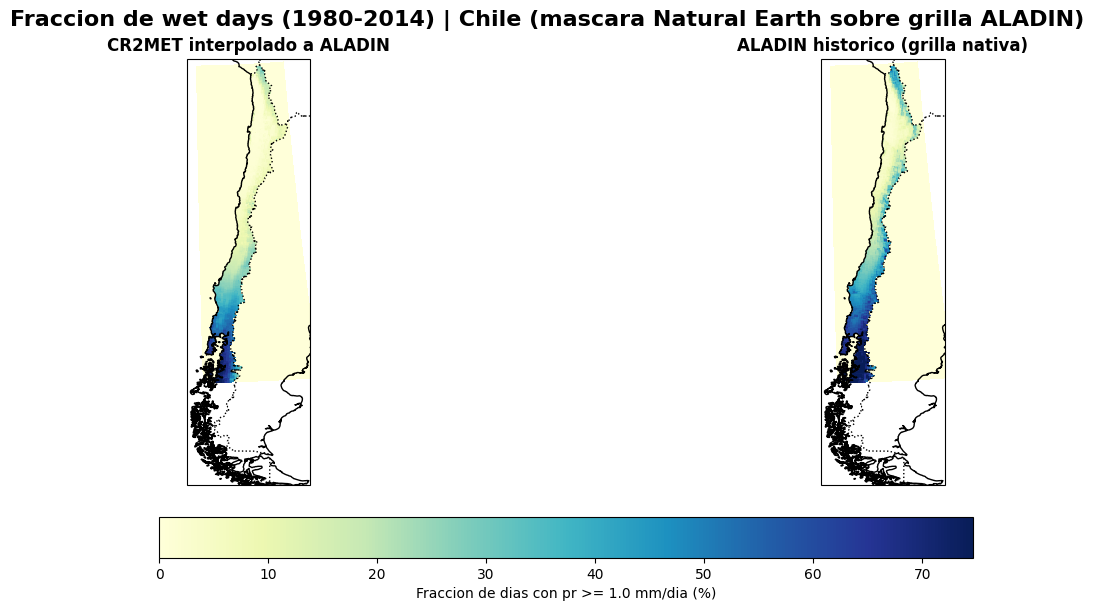

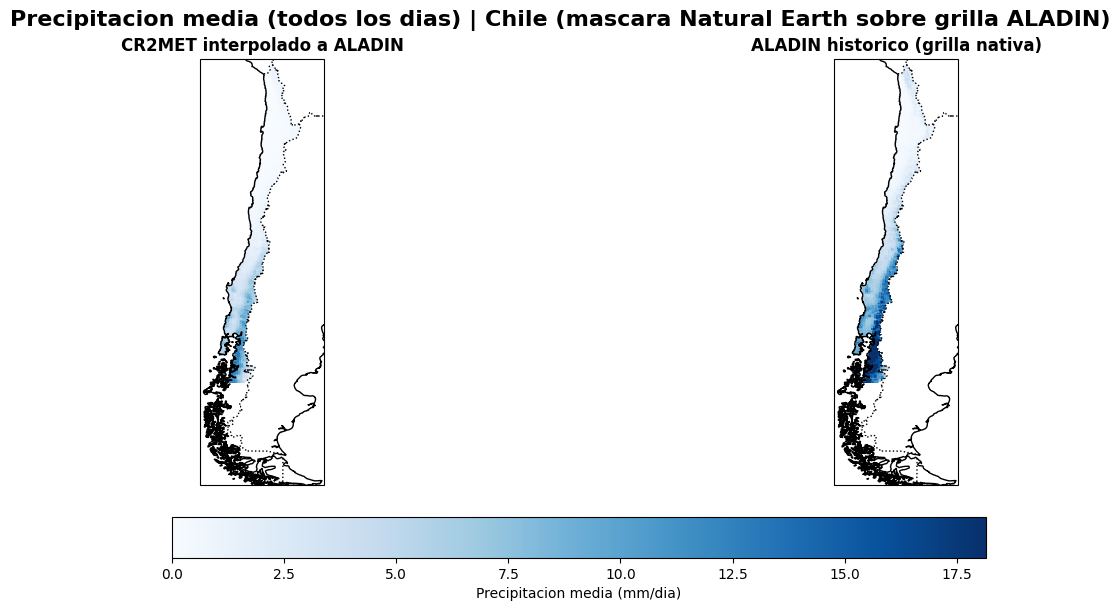

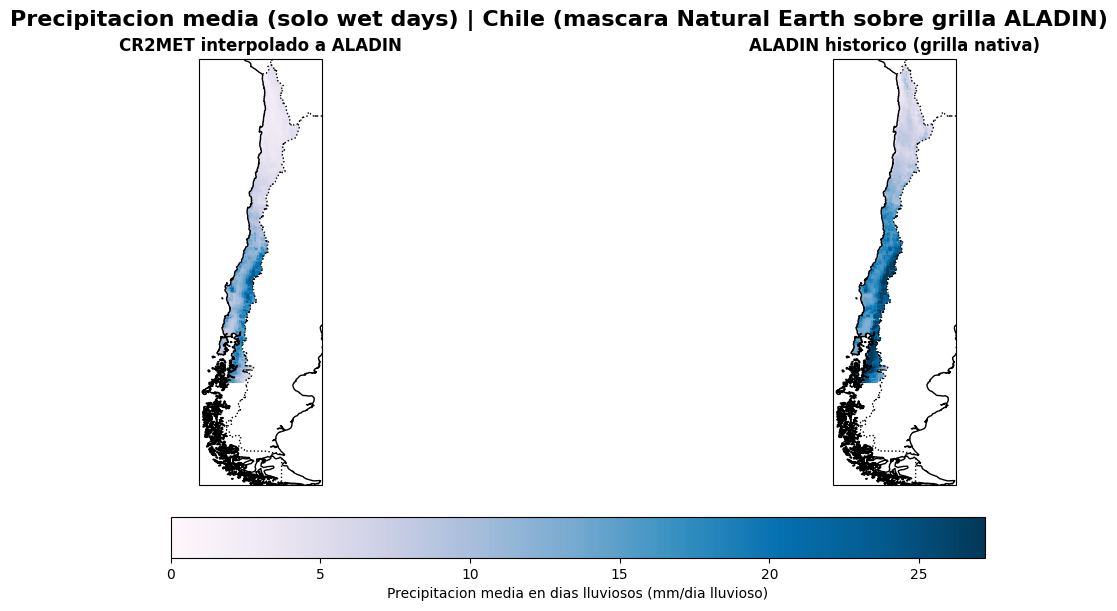

Metricas y mapas: mismo periodo, misma definicion de wet day, misma mascara de Chile y misma grilla ALADIN (CR2MET interpolado).


In [7]:
# =====================================================================
# MAPAS COMPARATIVOS (MISMA GRILLA Y MISMA MASCARA)
# =====================================================================
print('4/4: Graficando mapas comparativos...')

wet_vmax = float(
    np.nanpercentile(
        np.concatenate([
            wet_frac_cr2met.where(chile_mask).values.ravel(),
            wet_frac_aladin.where(chile_mask).values.ravel(),
        ]),
        98,
    )
)
wet_vmax = max(wet_vmax, 10.0)
plot_two_panel_maps(
    wet_frac_cr2met,
    wet_frac_aladin,
    title=f'Fraccion de wet days ({START_DATE[:4]}-{END_DATE[:4]}) | {DOMAIN_LABEL}',
    cbar_label='Fraccion de dias con pr >= 1.0 mm/dia (%)',
    cmap='YlGnBu',
    vmin=0.0,
    vmax=wet_vmax,
)

mean_all_vmax = float(
    np.nanpercentile(
        np.concatenate([
            mean_all_cr2met.where(chile_mask).values.ravel(),
            mean_all_aladin.where(chile_mask).values.ravel(),
        ]),
        98,
    )
)
mean_all_vmax = max(mean_all_vmax, 1.0)
plot_two_panel_maps(
    mean_all_cr2met,
    mean_all_aladin,
    title=f'Precipitacion media (todos los dias) | {DOMAIN_LABEL}',
    cbar_label='Precipitacion media (mm/dia)',
    cmap='Blues',
    vmin=0.0,
    vmax=mean_all_vmax,
)

mean_wet_vmax = float(
    np.nanpercentile(
        np.concatenate([
            mean_wet_cr2met.where(chile_mask).values.ravel(),
            mean_wet_aladin.where(chile_mask).values.ravel(),
        ]),
        98,
    )
)
mean_wet_vmax = max(mean_wet_vmax, 1.0)
plot_two_panel_maps(
    mean_wet_cr2met,
    mean_wet_aladin,
    title=f'Precipitacion media (solo wet days) | {DOMAIN_LABEL}',
    cbar_label='Precipitacion media en dias lluviosos (mm/dia lluvioso)',
    cmap='PuBu',
    vmin=0.0,
    vmax=mean_wet_vmax,
)

print(
    'Metricas y mapas: mismo periodo, misma definicion de wet day, '
    'misma mascara de Chile y misma grilla ALADIN (CR2MET interpolado).'
)


## Significancia estadística: bootstrap por años (ALADIN − CR2MET)

Para cada píxel y métrica se calcula la **diferencia anual** ALADIN − CR2MET (1980–2014, 35 años).
Se aplica **bootstrap por años** (1 000 réplicas, remuestreo con reemplazo) para obtener el **IC95** de la diferencia media.

- **Significativo:** el IC95 **no incluye 0** (equivalente a rechazar que no hay sesgo a α = 0,05).
- **Hachurado:** celdas con diferencia significativa.
- Mapa de color: diferencia climatológica media observada (ALADIN − CR2MET).
- **Colores:** azul = ALADIN más húmedo (Δ > 0); rojo = ALADIN más seco (Δ < 0).


5/5: Bootstrap por anos para significancia estadistica...
  Anos en serie pareada: 35 | iteraciones: 1000 | IC95%
  Bootstrap: Fraccion de wet days...
  Bootstrap: Precipitacion media (todos los dias)...
  Bootstrap: Precipitacion media (solo wet days)...


,Metrica,Unidades delta,Delta medio espacial,Delta mediano espacial,% celdas significativas,% ALADIN > CR2MET (sig.),% ALADIN < CR2MET (sig.)
0,Fraccion de wet days,pp,9.740,9.285,97.017,95.539,1.478
1,Precipitacion media (todos los dias),mm/dia,2.826,2.097,99.721,99.387,0.335
2,Precipitacion media (solo wet days),mm/dia lluvioso,4.971,4.590,98.104,98.021,0.084



Graficando mapas de diferencia con hachurado (significativo)...


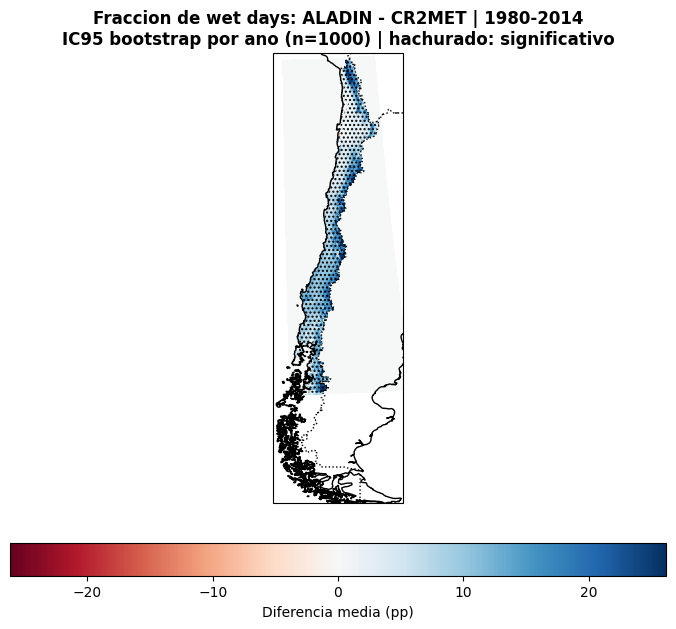

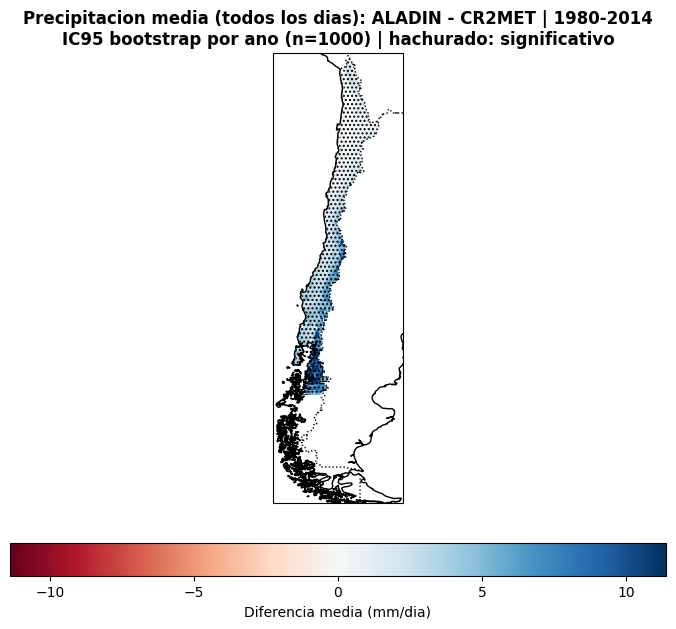

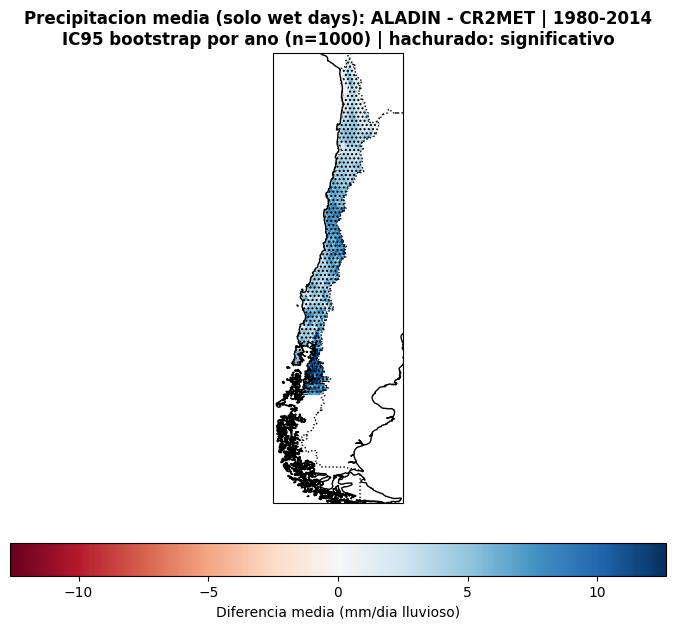


=== Resumen nacional (delta espacial medio) ===


,Metrica,Delta medio Chile,IC95 inf (media bootstrap),IC95 sup (media bootstrap)
0,Fraccion de wet days,9.740,8.137,11.304
1,Precipitacion media (todos los dias),2.826,2.508,3.154
2,Precipitacion media (solo wet days),4.971,4.096,5.853



=== Lectura rapida ===
- Fraccion de wet days: delta medio 9.74 pp | 97.0% celdas significativas | ALADIN > CR2MET (sig.) en 95.5%
- Precipitacion media (todos los dias): delta medio 2.83 mm/dia | 99.7% celdas significativas | ALADIN > CR2MET (sig.) en 99.4%
- Precipitacion media (solo wet days): delta medio 4.97 mm/dia lluvioso | 98.1% celdas significativas | ALADIN > CR2MET (sig.) en 98.0%

Nota: bootstrap usa 35 anos de interseccion temporal CR2MET-ALADIN (1980-01-01 a 2014-12-31).


In [8]:
# =====================================================================
# SIGNIFICANCIA POR BOOTSTRAP (DIFERENCIA ALADIN - CR2MET)
# =====================================================================
print('5/5: Bootstrap por anos para significancia estadistica...')
print(f'  Anos en serie pareada: {N_YEARS_COMMON} | iteraciones: {BOOTSTRAP_ITER} | IC{(1-ALPHA)*100:.0f}%')

annual_wet_cr2 = annual_wet_day_fraction(pr_cr2met_chile)
annual_wet_ala = annual_wet_day_fraction(pr_aladin_chile)
annual_all_cr2 = annual_mean_precip_all_days(pr_cr2met_chile)
annual_all_ala = annual_mean_precip_all_days(pr_aladin_chile)
annual_wetmean_cr2 = annual_mean_precip_wet_days(pr_cr2met_chile)
annual_wetmean_ala = annual_mean_precip_wet_days(pr_aladin_chile)

# RdBu: azul = ALADIN mas humedo (delta > 0), rojo = ALADIN mas seco (delta < 0)
bootstrap_specs = [
    ('wet_frac', annual_wet_cr2, annual_wet_ala, 'Fraccion de wet days', 'pp', 'RdBu', None, None),
    ('mean_all', annual_all_cr2, annual_all_ala, 'Precipitacion media (todos los dias)', 'mm/dia', 'RdBu', None, None),
    ('mean_wet', annual_wetmean_cr2, annual_wetmean_ala, 'Precipitacion media (solo wet days)', 'mm/dia lluvioso', 'RdBu', None, None),
]

bootstrap_results = {}
bootstrap_summary_rows = []

for key, ann_cr2, ann_ala, label, units, cmap, vmin, vmax in bootstrap_specs:
    print(f'  Bootstrap: {label}...')
    res = bootstrap_paired_mean_diff(ann_cr2, ann_ala, n_iter=BOOTSTRAP_ITER, seed=RANDOM_SEED)
    bootstrap_results[key] = res
    bootstrap_summary_rows.append(
        summarize_bootstrap_map(
            res['mean_diff'], res['significant'], res['sig_higher'], label, units,
        )
    )

bootstrap_summary = pd.DataFrame(bootstrap_summary_rows)
display(bootstrap_summary.round(3))

print('\nGraficando mapas de diferencia con hachurado (significativo)...')
for key, ann_cr2, ann_ala, label, units, cmap, vmin, vmax in bootstrap_specs:
    res = bootstrap_results[key]
    plot_diff_map_with_bootstrap(
        res['mean_diff'],
        res['significant'],
        title=(
            f'{label}: ALADIN - CR2MET | {START_DATE[:4]}-{END_DATE[:4]}\n'
            f'IC95 bootstrap por ano (n={BOOTSTRAP_ITER}) | hachurado: significativo'
        ),
        cbar_label=f'Diferencia media ({units})',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

national_rows = []
for key, _, _, label, units, _, _, _ in bootstrap_specs:
    res = bootstrap_results[key]
    diff_vals = res['mean_diff'].where(chile_mask).values.ravel()
    diff_vals = diff_vals[np.isfinite(diff_vals)]
    national_rows.append({
        'Metrica': label,
        'Delta medio Chile': float(np.mean(diff_vals)),
        'IC95 inf (media bootstrap)': float(res['ci_low'].where(chile_mask).mean().item()),
        'IC95 sup (media bootstrap)': float(res['ci_high'].where(chile_mask).mean().item()),
    })

national_bootstrap = pd.DataFrame(national_rows)
print('\n=== Resumen nacional (delta espacial medio) ===')
display(national_bootstrap.round(3))

print('\n=== Lectura rapida ===')
for _, row in bootstrap_summary.iterrows():
    print(
        f"- {row['Metrica']}: delta medio {row['Delta medio espacial']:.2f} {row['Unidades delta']} | "
        f"{row['% celdas significativas']:.1f}% celdas significativas | "
        f"ALADIN > CR2MET (sig.) en {row['% ALADIN > CR2MET (sig.)']:.1f}%"
    )
print(
    f'\nNota: bootstrap usa {N_YEARS_COMMON} anos de interseccion temporal CR2MET-ALADIN '
    f'({TIME_START_COMMON} a {TIME_END_COMMON}).'
)


## Conclusiones (significancia bootstrap) — 1980–2014

| Métrica | Δ medio | % celdas significativas | % ALADIN > CR2MET (sig.) |
|---|---|---|---|
| Fracción wet days | **+9,74 pp** | **97,0 %** | **95,5 %** |
| Precip. media (todos los días) | **+2,83 mm/día** | **99,7 %** | **99,4 %** |
| Precip. en wet days | **+4,97 mm/día** | **98,1 %** | **98,0 %** |

**IC95 del delta medio Chile (bootstrap):** wet days [8,1; 11,3] pp · media diaria [2,5; 3,2] mm/d · wet days [4,1; 5,9] mm/d.

1. El sesgo húmedo de ALADIN respecto a CR2MET (mismo τ = 1 mm) es **robusto en casi todo Chile**: el hachurado cubre ~97–100 % del territorio según la métrica.
2. No es solo frecuencia: ALADIN también intensifica más los días lluviosos (**+5,0 mm/día** en promedio, 98 % de celdas significativas).
3. Las pocas celdas sin significancia (< 3 %) y casi nula señal de ALADIN más seco (< 1,5 %) refuerzan que el sesgo es **sistemático y positivo** (más húmedo), no ruido espacial aleatorio.
4. Esto justifica la **calibración τ\*** (Pregunta 6): con 1 mm, CR2MET y ALADIN **no son intercambiables** ni descriptiva ni estadísticamente.
